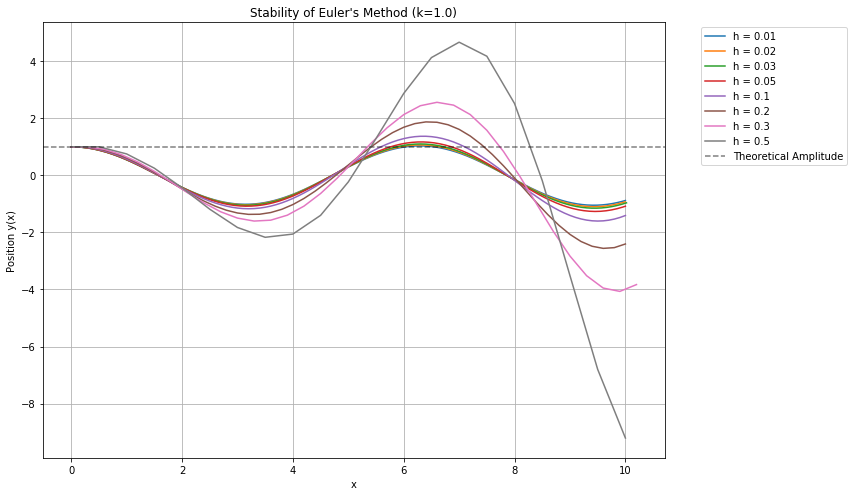

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(12, 7))

for h in h_values:
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    v_vals = np.zeros(len(x_vals))
    
    y_vals[0] = y_0
    v_vals[0] = v_0
    
    for i in range(1, len(x_vals)):
        # Forward Euler updates
        y_vals[i] = y_vals[i-1] + h * v_vals[i-1]
        v_vals[i] = v_vals[i-1] + h * (-k * y_vals[i-1])
        
    plt.plot(x_vals, y_vals, label=f'h = {h}')

plt.axhline(1, color='black', linestyle='--', alpha=0.5, label='Theoretical Amplitude')
plt.xlabel('x')
plt.ylabel('Position y(x)')
plt.title(f'Stability of Euler\'s Method (k={k})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

It's becoming unstable even at the smallest step size (h = 0.01). While it looks like a sine wave, the amplitude is gradually increasing over time. In a perfect physical system, the amplitude should remain constant at 1.0. Euler's Method introduces "numerical energy" into the system at every step, causing the solution to spiral outwards.

The Forward Euler method is unconditionally unstable for this type of oscillatory problem. However, it becomes visibly unstable as h increases. For h=0.01 to 0.1, the solution looks like a growing vibration. Once h reaches 0.3 or 0.5, the "overshoot" at each step is so large that the solution diverges exponentially and no longer resembles an oscillation.

Increasing k increases the "stiffness" of the system, which raises the frequency of the oscillations. As k increases, the instability happens much faster. And because the curve is sharper, the linear approximation used by Euler's method overshoots the actual curve more aggressively. A step size that looked okay for k=1 will cause the system to diverge much sooner if k=10.

Euler’s Method is fundamentally ill-suited for solving second-order oscillatory differential equations over long periods. Larger h's increase the step size and only compounds the error faster. Because the local truncation error is O(h^2), a larger h makes the "overshoot" grow quadratically. To solve this accurately with larger step sizes, you would need a more stable integrator like Runge-Kutta, which is designed to conserve the energy of the system.